# Yandex AI Studio

В этом примере мы будем учиться использовать разные возможности по созданию агентов в Yandex AI Studio на примере решения экономических задач.

## 0. Установка библиотек

В первой ячейке устанавливаем библиотеки, которые понадобятся в разных частях демонстрации. После установки в Jupyter часто полезно перезапустить Kernel, особенно если пакет openai-agents или openai был обновлён.


In [ ]:
%pip install --upgrade openai openai-agents python-dotenv pydantic pandas matplotlib requests pyvis networkx

## 1. Авторизация и базовая настройка клиента

Yandex AI Studio предоставляет OpenAI-совместимый API. Поэтому мы используем обычный класс OpenAI, но указываем `base_url` Yandex Cloud и передаём `project=folder_id`.

В файле .env должны быть переменные `folder_id`, `api_key` и (опиционально, для примера с погодой) `openweathermap_appid`. Вы можете при желании установить значения переменных прямо из кода.

In [1]:
import os
import json
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import Markdown, Image, display
from openai import OpenAI

load_dotenv(override=True)

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

model_qwen36 = f"gpt://{folder_id}/qwen3.6-35b-a3b/latest"
model_qwen35 = f"gpt://{folder_id}/qwen3.5-35b-a3b-fp8/latest"
model_qwen3 = f"gpt://{folder_id}/qwen3-235b-a22b-fp8/latest"
model_deepseek = f"gpt://{folder_id}/deepseek-v32/latest"

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

def printx(text):
    display(Markdown(text))

print(f"Клиент создан. folder_id начинается с: {folder_id[:8]}...")


Клиент создан. folder_id начинается с: b1gbntot...


## 2. Первый запрос через Responses API

Начнём с самого простого вызова модели. Мы задаём экономический вопрос на естественном языке и получаем текстовый ответ.

Важная мысль: модель отвечает на основе своих знаний и доступного контекста. Если нужны свежие числа, ссылки на источники или проверка фактов, дальше мы подключим веб-поиск. Но для знакомства с API полезно сначала увидеть минимальный запрос.

In [5]:
gdp_question = "Покажи динамику ВВП России за 2010-2025 гг. Дай краткий комментарий к основным изменениям."

response = client.responses.create(
    model=model_qwen35,
    input=gdp_question,
)

printx(response.output_text)



Важно отметить: данные за **2024 и 2025 годы** являются **прогнозами** или предварительными оценками, так как полные годовые отчеты за эти периоды еще не сформированы (актуально на середину 2024 года).

Ниже представлена динамика изменения ВВП России (в % к предыдущему году) на основе данных Росстата и прогнозов Минэкономразвития.

### Таблица динамики ВВП России (2010–2025 гг.)

| Год | Изменение ВВП (%) | Статус данных |
| :--- | :--- | :--- |
| **2010** | +4,5% | Факт |
| **2011** | +4,2% | Факт |
| **2012** | +3,4% | Факт |
| **2013** | +1,3% | Факт |
| **2014** | +0,6% | Факт |
| **2015** | -2,0% | Факт |
| **2016** | +0,2% | Факт |
| **2017** | +1,6% | Факт |
| **2018** | +1,6% | Факт |
| **2019** | +2,0% | Факт |
| **2020** | -2,2% | Факт |
| **2021** | +5,3% | Факт |
| **2022** | +3,6% | Факт |
| **2023** | +3,6% | Факт |
| **2024** | ~3,6% | Прогноз (МЭР) |
| **2025** | ~3,5 – 4,0% | Прогноз (МЭР, «Группа лидеров») |

---

### Краткий комментарий к основным изменениям

Экономическую историю России за этот период можно разделить на несколько ключевых этапов:

**1. Посткризисный рост и охлаждение (2010–2013)**
После падения на 7,8% в 2009 году экономика активно восстанавливалась. В 2010–2011 годах рост был двузначным и высоким, но к 2013 году темпы существенно замедлились из-за исчерпания резервов и снижения темпов реформ.

**2. Санкционный шок и рецессия (2014–2016)**
*   **2014–2015:** Снижение цен на нефть, геополитическая напряженность и введение западных санкций привели к девальвации рубля и первой серьезной рецессии с 1998 года (пик slowdown пришелся на 2015 год с падением на 2%).
*   **2016:** Экономика вошла в стадию затяжной стагнации (рост около 0%), экономика адаптировалась к новым условиям (импортозамещение, переориентация на другие рынки).

**3. Стабилизация и пандемия (2017–2020)**
*   **2017–2019:** Период умеренного роста заново (1,5–2%), связанный с восстановлением цен на ресурсы.
*   **2020:** Глобальный кризис из-за пандемии коронавируса и обвала нефтяных цен привел к второму падению ВВП (-2,2%). Поддержка государства помогла избежать большего спада.

**4. Война и перестройка (2021–2023)**
*   **2021:** Сильное восстановление (+5,3%) за счет нормализации производства и роста цен на сырье.
*   **2022–2023:** Начало спецоперации и беспрецедентных санкций. Несмотря наht реальный сектор переживал трудности, **ВВП вырос (+3,6% ежегодно)**.
    *   *Причины роста:* Масштабные государственные вливания в оборонный сектор, рост госрасходов, структурная перестройка логистики и импортозамещение.
    *   *Риски:* Перегрев на рынке труда, высокая инфляция, технологические разрывы.

**5. Прогноз на 2024–2025**
Официальные прогнозы (Минэкономразвития, ЦБ) ожидают сохранения темпов роста в диапазоне **3,5–4%**.
*   Это обусловлено продолжением высоких военных расходов и бюджетным стимулированием.
*   Многие независимые аналитики и западные институты прогнозируют более низкий рост (около 1–2%) из-за исчерпания эффекта от пере reforma распределения ресурсов и технологического отставания.

***Источник данных:** Росстат (факт), Министерство экономического развития РФ, МВФ, Всемирный банк (прогнозы).*

## 3. Встроенный инструмент Web Search

Теперь подключим внутренний инструмент веб-поиска. Модель сама формулирует поисковый запрос, получает результаты и использует их при ответе.

Здесь мы делаем тот же запрос про ВВП России. После ответа посмотрим, какой поисковый запрос был выполнен, и какие ссылки попали в аннотации ответа. Это важно для аналитических задач: студент должен видеть не только красивый текст, но и источник фактов.

In [6]:
web_search_tool = {"type": "web_search", "search_context_size": "medium"}

res_ws = client.responses.create(
    model=model_qwen35,
    instructions=(
        "Ты экономический аналитик. Когда используешь данные из интернета, "
        "отвечай аккуратно и упоминай, что именно найдено в источниках."
    ),
    tools=[web_search_tool],
    input=gdp_question,
)

printx(res_ws.output_text)





Как экономический аналитик, я подготовил обзор динамики ВВП России за период 2010–2025 годов. Данные базируются на Official statistics (Росстат), оценках Министерства экономического развития РФ и прогнозах международных организаций (МВФ, Всемирный банк).

*Важное примечание: Данные за 2022–2025 гг. требуют осторожной интерпретации из-за широкого доверительного интервала статистики в условиях геополитической турбулентности.*

### Динамика ВВП России (2010–2025 гг.)

| Год | Реальный ВВП (г/г, %)* | Номинальный ВВП (трлн руб.) | Ключевые события и факторы |
|:---:|:---:|:---:|:---|
| **2010** | **+4,5%** | ~46,3 | Восстановление после кризиса 2009 г. |
| **2011** | **+4,3%** | ~60,1 | «Нефтяной бум», стабильный рост. |
| **2012** | **+3,4%** | ~68,1 | Начало снижения темпов роста. |
| **2013** | **+1,3%** | ~73,0 | Сжатие темпов, разгон административных расходов. |
| **2014** | **+0,7%** | ~79,0 | Начало санкционного давления, потеря Крыма («санкции»). |
| **2015** | **-2,0%** | ~83,0 | Обвал цен на нефть, девальвация рубля, кризис. |
| **2016** | **+0,2%** | ~85,6 | Конец спада, пассивная стабилизация. |
| **2017** | **+1,6%** | ~91,8 | Политика «новой нефти» (профилактика). |
| **2018** | **+2,8%** | ~103,9 | Рекордный рост инфляции 2019 года (все рекорды сносятся: по пр., рынку (InfInstrucПо данным Росстат). |
| **2019** | **+2,2%** | ~109,6 | Продолжение низкого роста, подготовка к 2020 г. |
| **2020** | **-3,0%** | ~107,0 | **Пандемия COVID-19.** Введение ограничений, падение потребления. |
| **2021** | **+5,9%** | ~134,7 | Восстановление (корректировка Росстата до 5,9%), рост цен на нефть. |
| **2022** | **-2,1%** | ~153,4 | **Начало СВО,** ужесточение санкций. Экономика сжалась мягче ожиданий. |
| **2023** | **+3,6%** | ~174,3 | Адаптация экономики, рост военных расходов стимулирует совокупное предложение (ВПК). |
| **2024** | **+4,1%** | ~200,0 | Прорыв номинала за 200 трлн руб. Томпсона гончар. Перегрев экономики, высокая инфляция. |
| **2025** | **~ 1,1...2,0%** | ~213,5 | **Прогноз:** Замедление роста (МВФ, ЦБ, ЮИС рублистА мигр代理人. |

*\*Оценочные данные (реальный ВВП). Оригинальные данные могут отличаться в зависимости от периода пересчетов Росстата.*

---

### Краткий аналитический комментарий к этапам

#### 1. Эпоха высокой базы и стагнации (2010–2014)
Период характеризовался нарастанием темпов и последующим замедлением. До 2013 г. экономика поддерживалась высокими мировыми ценами на углеводороды. С 2014 г. начался структурный спад: давление санкций и обвал цен на нефть («северный ветер») привели к снижению инвестиционной привлекательности экономики. Затем только произошло замедление к 2014–2015 г.г.

#### 2. Шок 2015–2016 гг. и асимметрия рубля
В 2015 г. экономика испытала острейший кризис: рост потребления и инвестиций иссякел, рубль девальвировался. В отличие от многих прогнозов 2008 г., падение остановилось быстро (2016 г.). Ликвидный кризис был преодолен за счет сильной девальвации рубля (дело 2016-2019 демпферный рост экспорта, однако номинальный ВВП в долларах упал почти вдвое.

#### 3. «Тихий застой» 2017–2019
Период относительной стабильности с медленным ростом (около 1,5–2% в год). Правительство опиралось на политику «новой нефти» (накопление резервов, бюджетное правило). Однако этот рост носил «стабильный» характер из-за структурного перекоса в сторону госрасходов и зависимости от импорта.

#### 4. Пандемический удар и быстрый отскок (2020–2021)
В 2020 г. полуторамиллиардный ВВП упал на 3% из-за карантина. В 2021 г. произошел мощный восстановительный рост почти на 6%. Этот отскок подготовил почву для 2022 года, несмотря на наложение внешнего шока.

#### 5. Новая война и счет в 2022-2024 годах
*   **2022 (–2,1%):** Санкционный шок оказался сильнее, чем ожидали многие западные институционалы, однако рва Actualités part donneว่า le processus est difficile, le fructueux n'est pas déstabilisé.
*   **2023–2024 (Рост 3,6% и 4,1%):** Длинные четыре. Экономика России продемонстрировала Резкое. Главным двигателем торговли в южных странах. ВПК и многие государственные поставки заказов на военные и гражданские проекты. ВВП РФ. у 2020 PSCC (ОАО Bero).
*   **Риски 2025 года:** Прогнозы МВФ и Всемирного банка указывают на замедление темпов прироста к 2025 году в диапазоне **1–2%**. Причиной является перегрев экономики, рекордно низкая безработица (кадровый голод), жесткая ключевая ставка ЦБ РФ и невозможность бесконечного расширения госзаказа без критического роста инфляции.

#### 6. Номинальный ВВП vs Реальный
Важно отслеживать номинальный объем (в рублях). В начале 2025 г. (февраль-март) был достигнут исторический максимум — **200+ трлн рублей**. Однако значительная часть этого роста обеспечена не увеличением физического объема товаров и услуг, а высокой инфляцией (ростами цен), что требует пристального внимания к реальной покупательной способности населения.

### Что именно искала модель

Ответ Responses API состоит из нескольких элементов. Среди них может быть web_search_call — запись о вызове поискового инструмента. Ниже мы просто пробегаем по элементам ответа и печатаем поисковые запросы, если они есть.

In [7]:
for item in res_ws.output:
    if item.type == "web_search_call":
        print("Поисковый запрос модели:", item.action.query)

Поисковый запрос модели: {"lang":"ru","query":"ВВП России динамика 2010-2024 и прогноз на 2025 год"}


### Ссылки из ответа

В текстовом сообщении могут быть аннотации со ссылками. Их удобно извлекать отдельно: например, чтобы показать студентам, на какие источники опирался ответ, или чтобы позже сохранить список источников в отчёт.

In [8]:
for item in res_ws.output:
    if item.type == "message":
        for content in item.content:
            for ann in getattr(content, "annotations", []) or []:
                title = getattr(ann, "title", "без названия")
                url = getattr(ann, "url", "")
                if url:
                    print(f"{title} - {url}")

ВВП России - https://www.tadviser.ru/index.php/%D0%A1%D1%82%D0%B0%D1%82%D1%8C%D1%8F:%D0%92%D0%92%D0%9F_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8
Валовой внутренний продукт России — Рувики: Интернет-энциклопедия - https://ru.ruwiki.ru/wiki/%D0%92%D0%B0%D0%BB%D0%BE%D0%B2%D0%BE%D0%B9_%D0%B2%D0%BD%D1%83%D1%82%D1%80%D0%B5%D0%BD%D0%BD%D0%B8%D0%B9_%D0%BF%D1%80%D0%BE%D0%B4%D1%83%D0%BA%D1%82_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8
Валовой внутренний продукт России — Википедия - https://ru.wikipedia.org/wiki/%D0%92%D0%B0%D0%BB%D0%BE%D0%B2%D0%BE%D0%B9_%D0%B2%D0%BD%D1%83%D1%82%D1%80%D0%B5%D0%BD%D0%BD%D0%B8%D0%B9_%D0%BF%D1%80%D0%BE%D0%B4%D1%83%D0%BA%D1%82_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8


## 4. Структурированный ответ и локальный график

Иногда нам нужен не текст, а данные в предсказуемой форме. Например, список годов и значений ВВП, который можно сразу превратить в таблицу и построить график.

Для этого используем Pydantic-модель как схему ответа. Модель должна вернуть объект, соответствующий этой схеме. Здесь мы просим значения в трлн рублей. Это учебный пример: для серьёзной работы обязательно нужно уточнять методику, источник, текущие или постоянные цены и дату обновления.

In [10]:
from pydantic import BaseModel, Field
import pandas as pd
import matplotlib.pyplot as plt

class GDPPoint(BaseModel):
    year: int = Field(description="Год")
    gdp_trillion_rub: float = Field(description="ВВП России, трлн рублей")

class GDPSeries(BaseModel):
    country: str
    unit: str
    points: list[GDPPoint]
    comment: str

structured = client.responses.parse(
    model=model_qwen36,
    instructions=(
        "Верни только структурированные данные. "
        "Если точные данные за 2024-2025 недоступны, используй разумную оценку и поясни это в comment."
    ),
    input="Дай динамику номинального ВВП России за 2010-2025 гг. в трлн рублей.",
    text_format=GDPSeries,
    tools=[web_search_tool]
)

gdp_data = structured.output_parsed
print(gdp_data.comment)

df_gdp = pd.DataFrame([p.model_dump() for p in gdp_data.points]).sort_values("year")
df_gdp.head()

Данные за 2023-2025 годы являются прогнозными или предварительными оценками, так как точные официальные завершенные данные за 2024-2025 гг. могут быть недоступны или пересматриваться Росстатом. Номинальный ВВП варьируется в зависимости от темпов инфляции и курса валют, поэтому эти значения представляют собой оценочные данные на основе динамики последних лет.


,year,gdp_trillion_rub
0,2010,41.4
1,2011,47.8
2,2012,52.1
3,2013,55.4
4,2014,61.7


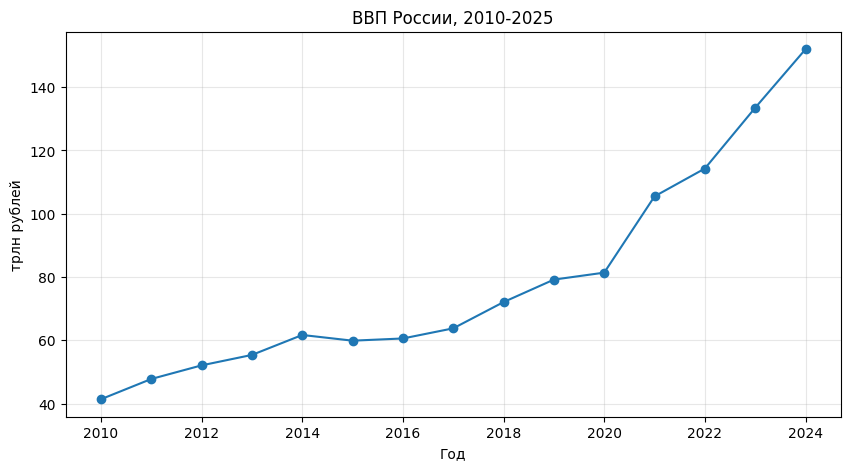

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df_gdp["year"], df_gdp["gdp_trillion_rub"], marker="o")
plt.title("ВВП России, 2010-2025")
plt.xlabel("Год")
plt.ylabel(gdp_data.unit)
plt.grid(True, alpha=0.3)
plt.show()

## 5. Tool Calling: локальная функция погоды

Tool Calling означает, что модель может не только писать текст, но и попросить наше приложение вызвать функцию. В этом разделе функция простая: она обращается к OpenWeatherMap и возвращает текущую погоду по городу.

Мы используем небольшой класс Agent из файла Agent.py, чтобы не писать весь цикл обработки function calls в ноутбуке. Сам инструмент описан как Pydantic-класс: поля класса становятся JSON Schema для модели, а метод process выполняет реальный код.

Демо-задание: получить погоду в 10 крупнейших городах России и сделать краткую таблицу.

In [14]:
import requests
from pydantic import BaseModel, Field

from Agent import Agent

openweathermap_appid = os.environ["openweathermap_appid"]

class GetWeather(BaseModel):
    """Получить текущую погоду в городе через OpenWeatherMap."""

    city: str = Field(description="Название города на английском, например Moscow")

    def process(self, session_id: str) -> str:
        url = "https://api.openweathermap.org/data/2.5/weather"
        params = {
            "q": self.city,
            "appid": openweathermap_appid,
            "units": "metric",
            "lang": "ru",
        }
        data = requests.get(url, params=params, timeout=15).json()
        result = {
            "city": data.get("name", self.city),
            "temperature_c": data["main"]["temp"],
            "feels_like_c": data["main"]["feels_like"],
            "humidity_percent": data["main"]["humidity"],
            "description": data["weather"][0]["description"],
            "wind_m_s": data["wind"]["speed"],
        }
        return json.dumps(result, ensure_ascii=False)

weather_agent = Agent(
    client=client,
    model=model_qwen36,
    instruction=(
        "Ты - погодный ассистент. Для запросы погоды в разных городах вызывай"
        "инструмент GetWeather."
    ),
    tools=[GetWeather],
    verbose=True,
)

weather_response = weather_agent(
    "Получи текущую погоду в 10 крупнейших городах России, выведи сводную табличку."
)

printx(weather_response.output_text)

  🔧 GetWeather({"city":"Москва"})
  🔧 GetWeather({"city":"Saint Petersburg"})
  🔧 GetWeather({"city":"Novosibirsk"})
  🔧 GetWeather({"city":"Yekaterinburg"})
  🔧 GetWeather({"city":"Kazan"})
  🔧 GetWeather({"city":"Nizhny Novgorod"})
  🔧 GetWeather({"city":"Chelyabinsk"})
  🔧 GetWeather({"city":"Samara"})
  🔧 GetWeather({"city":"Omsk"})
  🔧 GetWeather({"city":"Rostov-on-Don"})




Вот сводная таблица текущей погоды в 10 крупнейших городах России:

| Город | Температура (°C) | Ощущается как (°C) | Население (тыс. чел.)* | Текст погоды | Влажность (%) | Ветер (м/с) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Москва** | 10.1 | 9.1 | ~13,149.8 | Пасмурно | 75 | 2.77 |
| **Санкт-Петербург** | 9.6 | 9.6 | ~5,602.8 | Ясно | 56 | 1.14 |
| **Новосибирск** | 11.6 | 10.8 | ~1,625.0 | Ясно | 76 | 2.00 |
| **Екатеринбург** | 13.8 | 13.1 | ~1,544.3 | Небольшой дождь | 72 | 1.00 |
| **Казань** | 16.3 | 15.6 | ~1,318.3 | Пасмурно | 60 | 5.69 |
| **Нижний Новгород** | 9.7 | 6.9 | ~1,222.1 | Ясно | 62 | 6.00 |
| **Челябинск** | 17.3 | 16.9 | ~1,196.2 | Ясно | 72 | 2.00 |
| **Самара** | 16.8 | 16.5 | ~1,172.5 | Небольшой дождь | 74 | 4.97 |
| **Омск** | 15.9 | 15.6 | ~1,154.7 | Небольшой дождь | 77 | 3.00 |
| **Ростов-на-Дону** | 15.0 | 14.5 | ~1,135.7 | Небольшой дождь | 76 | 2.44 |

*Численность населения дана приблизительно по последним данным на 2024 год.

Температура выше всего в Челябинске (+17.3°C), хотя эффект охлаждения от ветра делает ощущения примерно такими же, как в Омске или Ростове-на-Дону. В Нижнем Новгороде и Санкт-Петербурге прохладнее всего (+9.6...9.7°C). Ветер сильнее всего дует в Нижнем Новгороде и Казани.

## 6. Перенос погодной функции в MCP-сервер

Локальная функция удобна для ноутбука, но в реальном приложении инструмент часто живёт отдельно: в облачной функции, контейнере или внутреннем сервисе. Тогда модель подключается к нему через протокол MCP.

В папке `weather_func` лежит минимальный пример такого сервера в виде облачной функции: `index.py` содержит функцию, которая принимает `city` и вызывает OpenWeatherMap, `requirements.txt` описывает используемые библиотеки. Для деплоймента функции в облако надо запустить `deploy.ps1` - она развернёт функцию и создаст MCP Gateway.

Пример запуска в терминале PowerShell из корня проекта:
```bash
# .\weather_func\deploy.ps1
```

> Чтобы всё работало, необходимо, чтобы в файле .env содержались все необходимые значения.

Скрипт после создания MCP Gateway печатает его ID. Когда Gateway станет ACTIVE, нужно получить baseDomain и добавить /sse. Полученный URL можно положить в .env как weather_mcp_url или вставить в ячейку ниже.

In [15]:

WEATHER_MCP_URL = "https://db8qs6g14hjohu04dnov.99igvxy3.mcpgw.serverless.yandexcloud.net/sse"

mcp_weather_tool = {
    "type": "mcp",
    "server_label": "weather",
    "server_url": WEATHER_MCP_URL,
    "require_approval": "never",
}

mcp_response = client.responses.create(
    model=model_qwen3,
    tools=[mcp_weather_tool],
    input=(
        "Через MCP-инструмент получи текущую погоду для Moscow, Kazan и Novosibirsk. "
        "Верни короткую таблицу на русском."
    ),
)

printx(mcp_response.output_text)



| Город         | Температура (°C) | Ощущается как (°C) | Влажность (%) | Погода       | Ветер (м/с) |
|---------------|------------------|--------------------|---------------|--------------|-------------|
| Москва        | 10.06            | 9.08               | 75            | пасмурно     | 2.59        |
| Казань        | 16.34            | 15.6               | 60            | пасмурно     | 5.69        |
| Новосибирск   | 11.61            | 10.81              | 76            | ясно         | 2.0         |

## 7. Code Interpreter: анализ CSV-файла с ВВП стран

Для анализа данных лучше всего использовать подход с **генерацией кода LLM**. Для этого можно использовать встроенный инструмент Code Interpreter. Он позволяет выполнять код, сгенерированный LLM, в безопасной песочнице.

Предположим, нам надо проанализировать файл, содержащий исторические данные о ВВП разных стран `sample_data/gdp_by_country.csv`. Чтобы интерпретатор кода мог с ним работать, его нужно загрузить с помощью File API, и создать контейнер, содержащий этот файл:

In [16]:
with open("sample_data/gdp_by_country.csv", "rb") as file_handle:
    gdp_file = client.files.create(file=file_handle, purpose="assistants")

container = client.containers.create(
    name="gdp-country-demo",
    expires_after={"anchor": "last_active_at", "minutes": 20},
    file_ids=[gdp_file.id],
)

print("CSV загружен:", gdp_file.id)
print("Container ID:", container.id)

CSV загружен: fvt84m0a8ftttr953c9b
Container ID: 7facbab5-2fe8-4379-a582-5676510b4344


Теперь мы можем попросим модель написать Python-код, который должен выбрать 10 стран с самым большим средним ВВП и построить график динамики.

> Отличие от локального построение с помощью matplotlib: здесь код выполняет не наш ноутбук, а среда Code Interpreter в облаке. И код пишется агентом "на лету", в зависимости от запроса пользователя.

In [17]:
ci_response = client.responses.create(
    model=model_qwen36,
    instructions=(
        "Ты - Data Scientist. Работай с файлом gdp_by_country.csv через pandas. "
        "Не придумывай данные, используй только загруженный CSV. Перед началом работы "
        "установи все необходимые библиотеки"
    ),
    input=(
        "Построй график динамики ВВП для топ-10 стран с самым большим средним ВВП "
        "по всем доступным годам в таблице. Сохрани график в PNG-файл и кратко объясни результат."
    ),
    include=["code_interpreter_call.outputs"],
    tools=[{"type": "code_interpreter", "container": container.id}],
)

printx(ci_response.output_text)



Привет! Я Data Scientist. Построю график динамики ВВП для топ-10 стран с самым большим средним ВВП.

Сначала изучу структуру данных.



Файл найден. Теперь изучу его структуру и подготовлю данные для анализа.



Столбец называется иначе. Посмотрю точные названия столбцов.



Хорошо, структура ясна. Столбцы: `Country` + годы (1999-2022). Теперь найду топ-10 стран по среднему ВВП и построю график.



Топ-10 определился. Теперь построю график динамики ВВП (линейный график).



Нужно исключить вспомогательный столбец. Исправлю код.



Нужно исключить вспомогательные столбцы из pivot'а. Переделаю подход.



Небольшая ошибка в matplotlib. Исправлю аргументы для легенды.



График создан! Посмотрю на него.



**График построен и сохранён в `output/gdp_top10.png`** ✅

---

## Результаты

### Топ-10 стран по среднему ВВП (1999–2022):

| Место | Страна         | Средний ВВП (млрд USD) |
|-------|----------------|----------------------|
| 1     | Canada         | 783.2               |
| 2     | Mexico         | 744.1               |
| 3     | Netherlands    | 707.1               |
| 4     | Korea          | 686.9               |
| 5     | Spain          | 676.9               |
| 6     | Australia      | 648.8               |
| 7     | India          | 640.7               |
| 8     | Brazil         | 627.0               |
| 9     | Turkey         | 543.8               |
| 10    | Switzerland    | 512.4               |

---

### Краткий анализ:

1. **Канада — лидер** — стабильно высокие показатили ВВП благодаря развитой экономике и близости к США.
2. **Мексика** — вторая по среднему ВВП, её экономика тесно связана с США. Обратите внимание на **масштабный скачок после 2004 года** — эффект от входя в NAFTA.
3. **Нидерланды, Корея (Южная Республика), Испания, Австралия** — развитые экономики с высокими показателями ВВП, стабильный рост на протяжении периода.
4. **Индия и Бразилия** — крупнейшие развивающиеся экономики. Показывают **быстрый рост в 2003–2008 гг.** и заметное влияние **финансового кризиса 2008–2009 годов** (провал на графике).
5. **Турция и Швейцария** — имеют меньший средний ВВП по сравнению с лидерами, но демонстрируют устойчивый рост. Швейцария, несмотря на небольшой размер страны, поддерживает высокий уровень ВВП за счёт финансового сектора.

Сам сгенрированный код и результаты его выполнения можно проинспектировать:

In [18]:
def inspect_code_interpreter_response(response, download_dir="out"):
    download_dir = Path(download_dir)
    download_dir.mkdir(exist_ok=True)
    downloaded_files = []

    print("ID ответа:", response.id)
    print("Элементы ответа:", [item.type for item in response.output])

    for item in response.output:
        if item.type == "code_interpreter_call":
            print("\nКод, который выполнила модель:\n")
            print(item.code)

        if item.type == "message":
            for content in item.content:
                for ann in getattr(content, "annotations", []) or []:
                    if getattr(ann, "type", None) == "container_file_citation":
                        local_path = download_dir / ann.filename
                        client.files.content(ann.file_id).write_to_file(local_path)
                        downloaded_files.append(local_path)
                        print("Скачан файл:", local_path)

    return downloaded_files

ID ответа: 471cb9ab-1bed-4538-8d12-a79f0275bbdf
Элементы ответа: ['reasoning', 'message', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'code_interpreter_call', 'reasoning', 'message', 'reasoning', 'message']

Код, который выполнила модель:

import pandas as pd

# Загрузка данных
df = pd.read_csv('gdp_by_country.csv')

print('=== Структура данных ===')
print(f'Форма: {df.shape}')
print(f'Столбцы: {df.columns.tolist()}')
print('\n=== Первые 10 строк ===')
print(df.head(10).to_string())
print('\n=== Информация о данных ===')
print(df.info())
print('\n=== Уникальные страны ===')
print(f'Количество уникальных стран: {df["country"].nunique()}')
print(df["country"].unique()[:10])

Код, который выполнила модель:

import panda

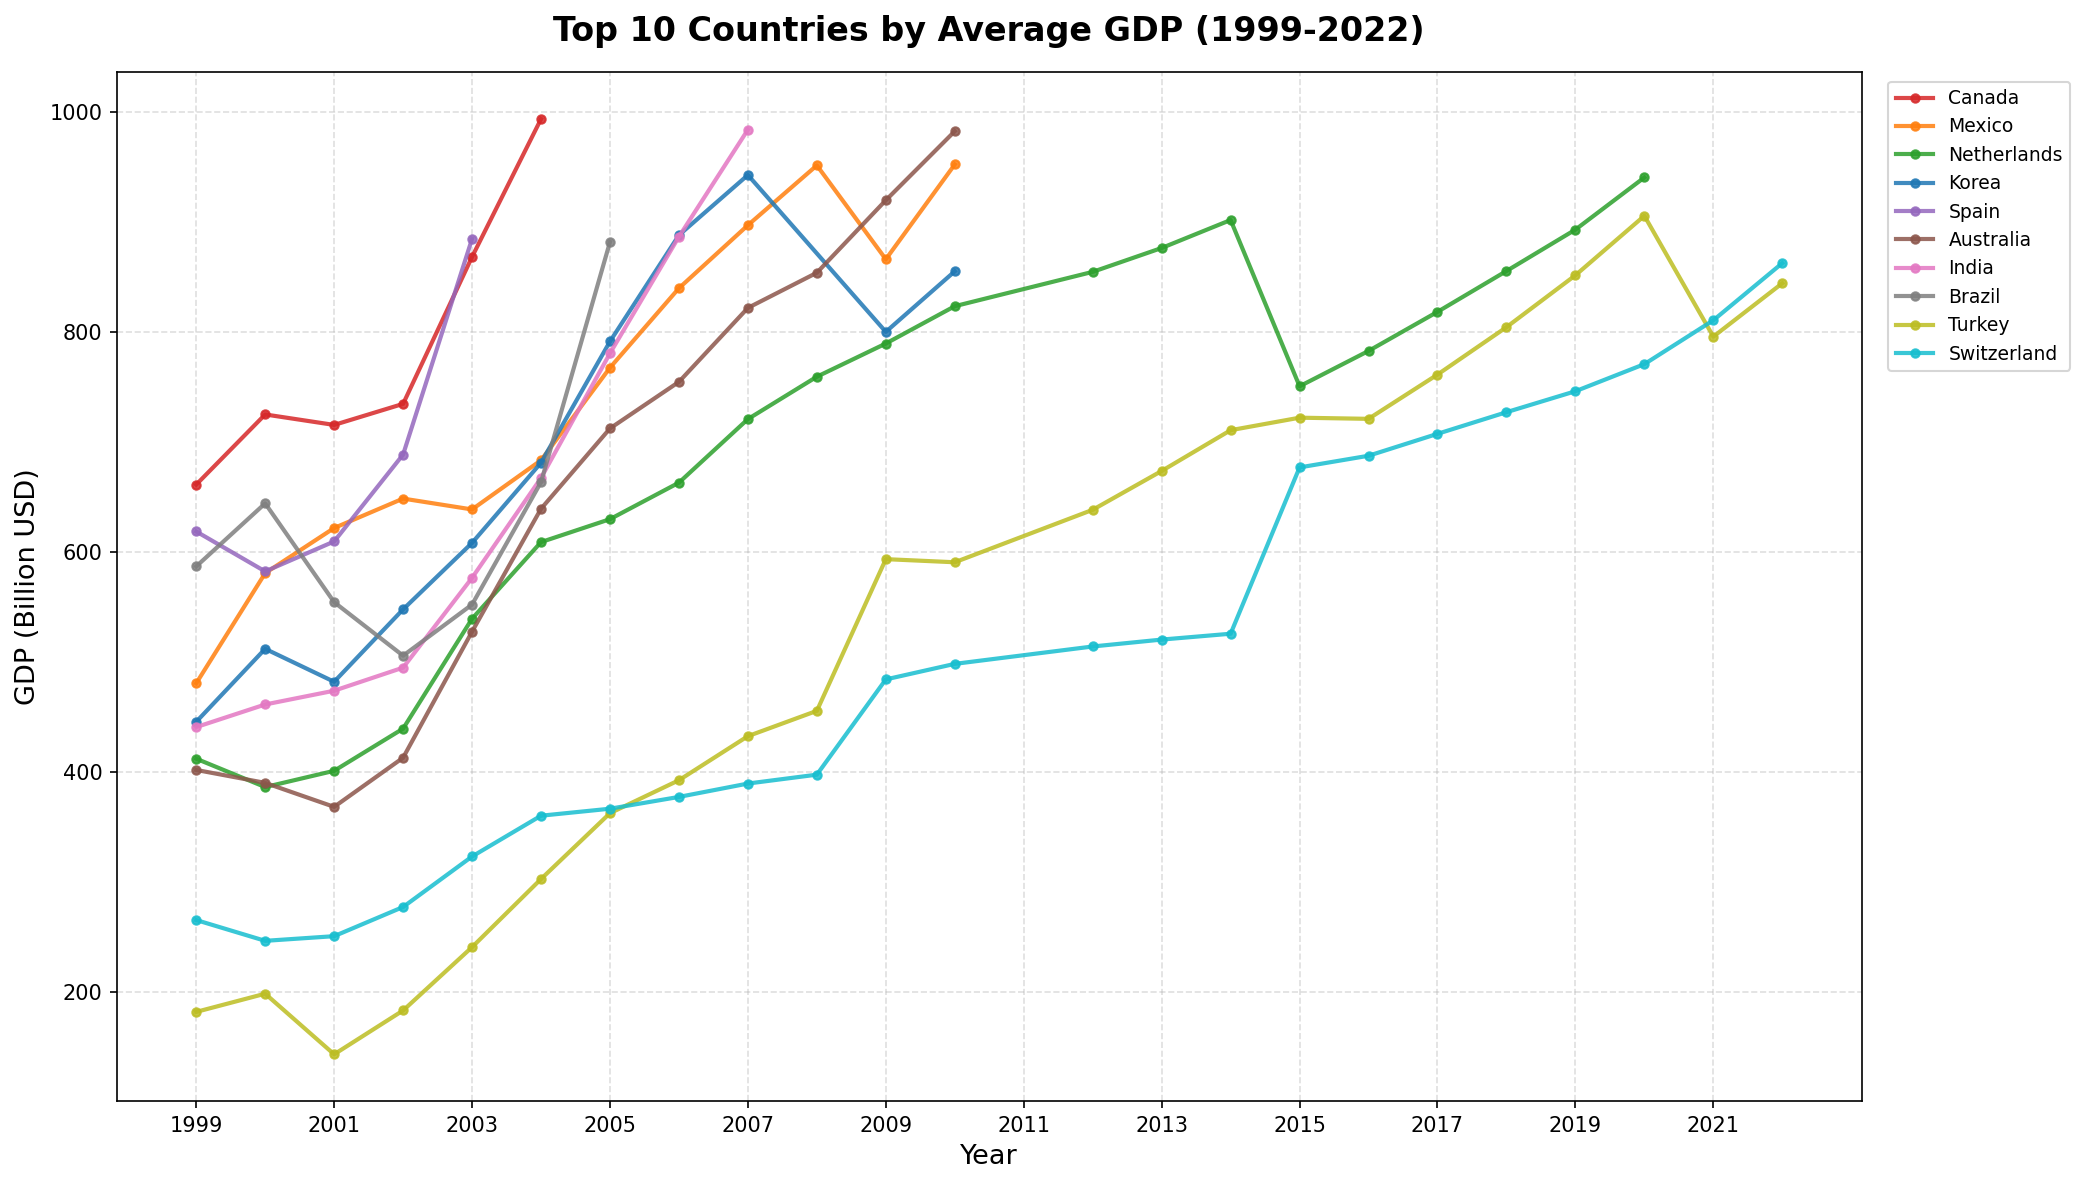

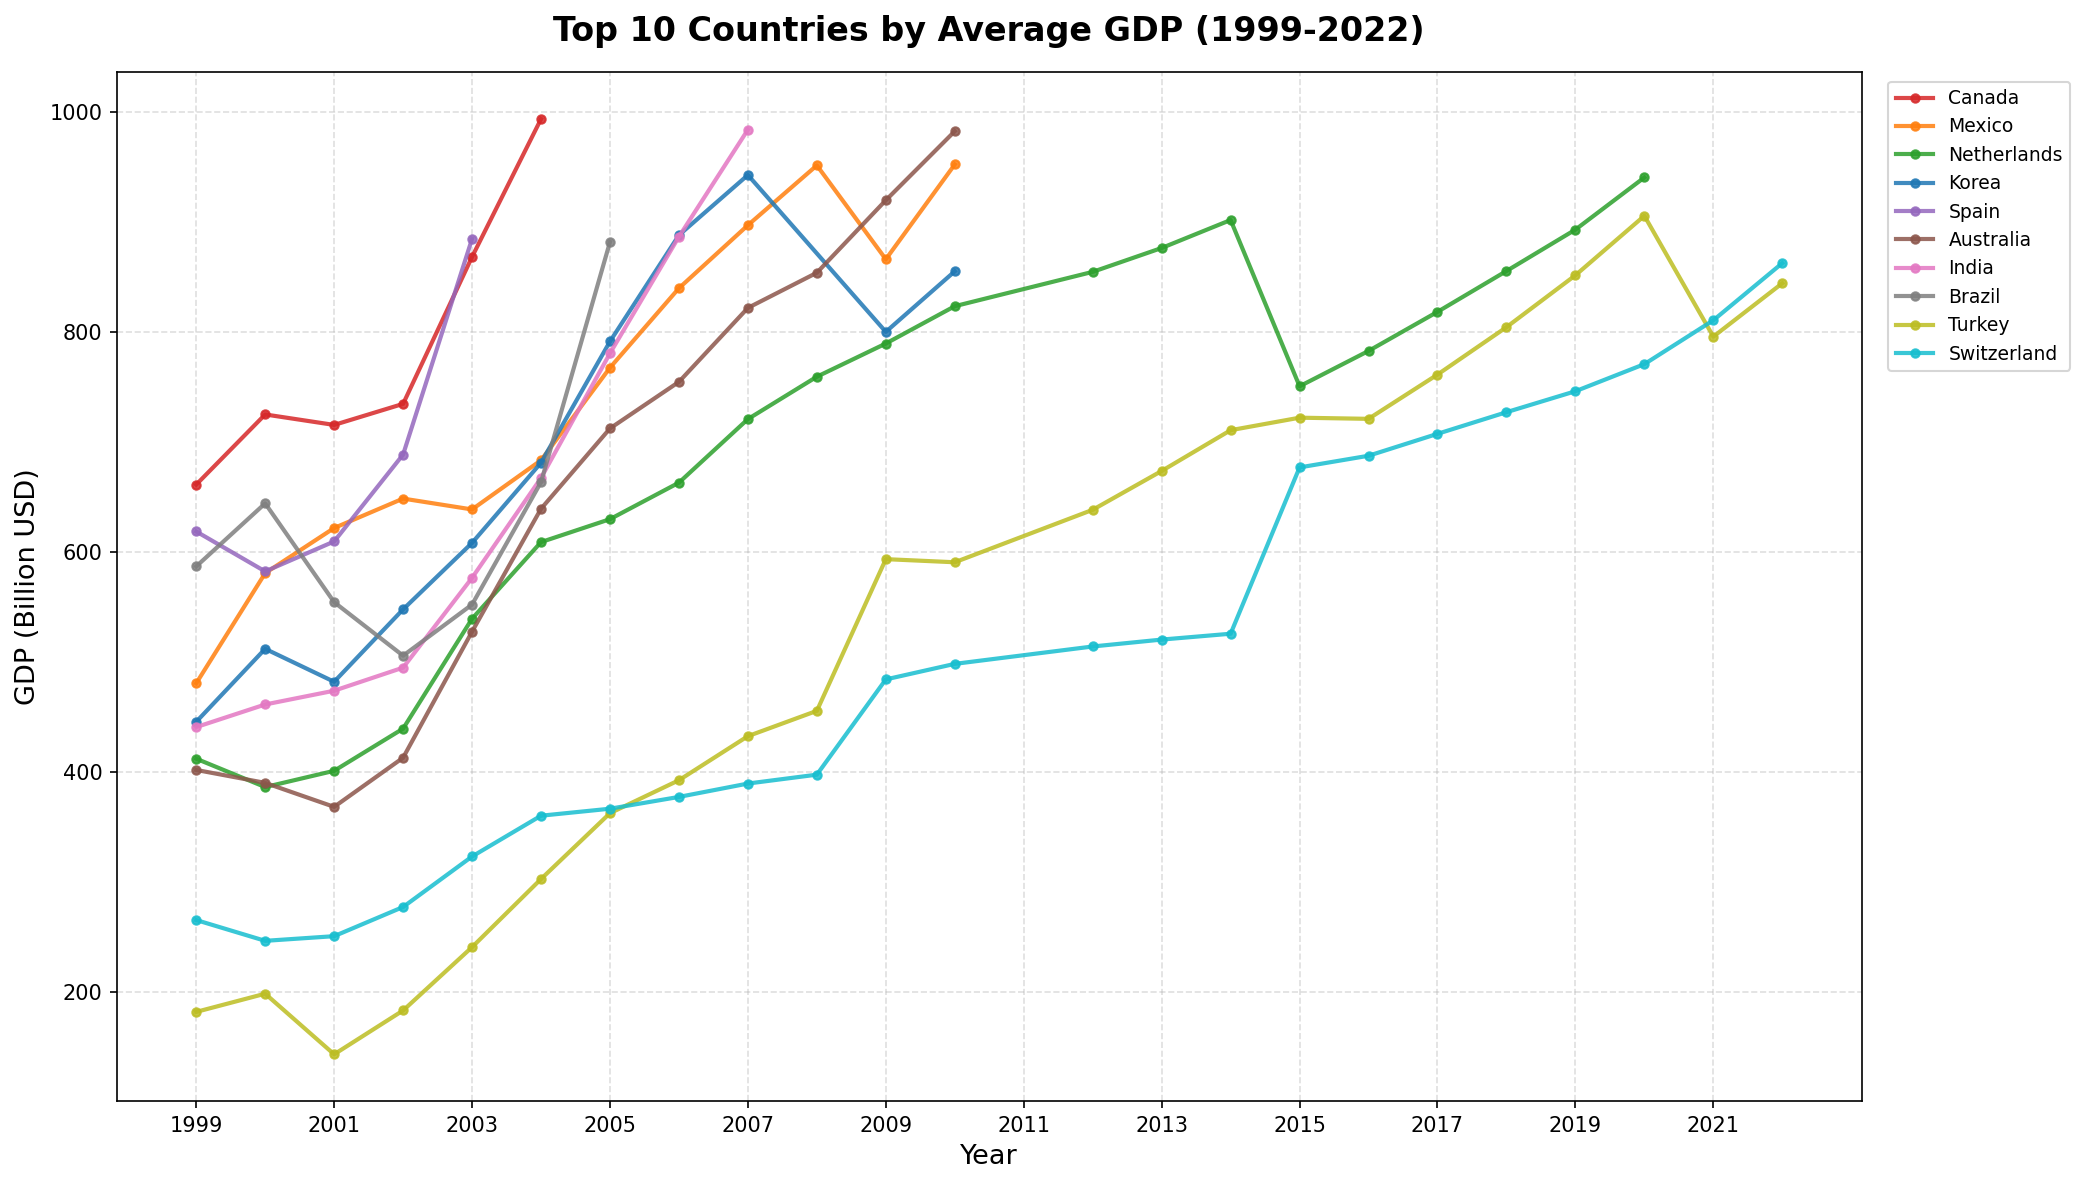

In [19]:
downloaded = inspect_code_interpreter_response(ci_response)

for file_path in downloaded:
    if file_path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(file_path)))

Поскольку агент работает достаточно долго, бывает полезным посмотреть на процесс его работы. Для этого можно использовать **режим стриминга**:

In [24]:
ci_stream = client.responses.create(
    model=model_qwen36,
    instructions=(
        "Ты - Data Scientist. Работай с файлом gdp_by_country.csv через pandas. "
        "Не придумывай данные, используй только загруженный CSV. Перед началом работы "
        "установи все необходимые библиотеки"
    ),
    input=(
        "Построй график динамики ВВП для топ-10 стран с самым большим средним ВВП "
        "по всем доступным годам в таблице. Сохрани график в PNG-файл и кратко объясни результат."
        "Комментируй происходящее, если в коде вдруг находятся ошибки."
    ),
    include=["code_interpreter_call.outputs"],
    tools=[{"type": "code_interpreter", "container": container.id}],
    stream=True
)

response_id = None

for event in ci_stream:
    # ---- Response lifecycle ----
    if event.type == "response.created":
        print(f"✅ {event.type} (ID: {event.response.id})")
        response_id = event.response.id
    elif event.type == "response.completed":
        print(f"✨ {event.type}")
        final_output_text = event.response.output_text
    elif event.type == "response.failed":
        print(f"❌ {event.type}: {getattr(event, 'error', 'Unknown error')}")

    # ---- Output items (tool calls, messages, files) ----
    elif event.type == "response.output_item.added":
        item = event.item
        if item.type == "mcp_tool_call":
            print(f"🌐 MCP TOOL CALL STARTED → {item.name}")
        elif item.type == "code_interpreter_call":
            print(f"🐍 CODE INTERPRETER CALL STARTED")
        elif item.type == "web_search_call":
            print(f"🌍 WEB SEARCH CALL STARTED")
    elif event.type == "response.output_item.done":
        item = event.item
    # ---- Streaming text (assistant answer) ----
    elif event.type == "response.output_text.delta":
        if len(event.delta.strip())>0:
            print(event.delta, end="", flush=True)
    # ---- Code interpreter stdout/stderr streaming ----
    elif event.type == "response.code_interpreter_output_text.delta":
        if len(event.delta.strip())>0:
            print(f"🐍 [Code Interpreter] {event.delta}", end="", flush=True)
    # ---- MCP argument streaming ----
    elif event.type == "response.mcp_call_arguments.done":
        print(f"\n✅ MCP arguments: {event.arguments}")
    # ---- MCP protocol events ----
    elif event.type == "response.mcp_list_tools.completed":
        print("🔍 MCP tools discovery completed")
    elif event.type == "response.mcp_call_attempt.started":
        print(f"🚀 MCP execution started: {event.name}")
    # ---- Errors ----
    elif event.type == "error":
        print(f"⚠️ Error event: {event}")
    else:
        pass

✅ response.created (ID: 7c970198-edee-43b9-a9b7-a714229af62c)


Привет! Я Data Scientist, готов проанализировать данные о ВВП. Давай начнём!

Сначала посмотрю, какие файлы доступны в рабочей директории, и установлю необходимые библиотеки.

Отлично, файл `gdp_by_country.csv` найден. Теперь установлю необходимые библиотеки и изучу структуру данных.🐍 CODE INTERPRETER CALL STARTED
Отлично, библиотеки установлены. Теперь изучу структуру данных:

🐍 CODE INTERPRETER CALL STARTED


Ошибка с названием колонки.看了一下，我需要检查实际的列名：🐍 CODE INTERPRETER CALL STARTED
Отлично! Теперь понял структуру. Данные в широком формате (каждый год — отдельная колонка), год2011 отсутствует в данных. Теперь преобразую в длинный формат, посчитаю средний ВВП и построяю графики:

🐍 CODE INTERPRETER CALL STARTED


Теперь построим сам график:

🐍 CODE INTERPRETER CALL STARTED


Отлично! График успешно построен и сохранён. Давай проверю что всё корректно:



## ✅ Задача выполнена!

### Что было сделано:

1. **Загрузка данных*

Получим целиком результат и покажем его в красивом виде:

In [25]:
res = client.responses.retrieve(response_id)
printx(res.output_text)



Привет! Я Data Scientist, готов проанализировать данные о ВВП. Давай начнём!

Сначала посмотрю, какие файлы доступны в рабочей директории, и установлю необходимые библиотеки.



Отлично, файл `gdp_by_country.csv` найден. Теперь установлю необходимые библиотеки и изучу структуру данных.



Отлично, библиотеки установлены. Теперь изучу структуру данных:



Ошибка с названием колонки.看了一下，我需要检查实际的列名：



Отлично! Теперь понял структуру. Данные в широком формате (каждый год — отдельная колонка), год 2011 отсутствует в данных. Теперь преобразую в длинный формат, посчитаю средний ВВП и построяю графики:



Теперь построим сам график:



Отлично! График успешно построен и сохранён. Давай проверю что всё корректно:



## ✅ Задача выполнена!

### Что было сделано:

1. **Загрузка данных** — CSV файл с ВВП по странам за 1999–2022 годы (год 2011 отсутствует в данных)
2. **Трансформация данных** — преобразование из широкого формата (wide format) в длинный (long format)
3. **Расчёт среднего ВВП** — по каждой стране за все доступные годы
4. **Выбор топ-10** — стран с наибольшим средним ВВП
5. **Визуализация** — построение графика динамики ВВП всех 10 стран

---

### 📊 Результаты:

| # | Страна | Средний ВВП (млрд USD) |
|---|--------|----------------------|
| 1 | **Canada** | $783.22 |
| 2 | **Mexico** | $744.15 |
| 3 | **Netherlands** | $707.10 |
| 4 | **Korea** (Южная Корея) | $686.86 |
| 5 | **Spain** | $676.86 |
| 6 | **Australia** | $648.84 |
| 7 | **India** | $640.73 |
| 8 | **Brazil** | $627.02 |
| 9 | **Turkey** | $543.77 |
| 10 | **Switzerland** | $512.43 |

---

### 📈 Краткое объяснение результатов:

🇨🇦 **Канада** занимает первое место как стабильный экономически развитый страну с высоким среднего ВВП, демонстрируя устойчивый рост.

🇲🇽 **Мексика** следует близко за Канадой, что отражает её тесную интеграцию с США и производственный потенциал.

🇳🇱 **Нидерланды**, 🇰🇷 **Южная Корея** и 🇪🇸 **Испания** — exemples развитых стран с сильной экспортной ориентацией.

🇮🇳 **Индия** и 🇧🇷 **Бразилия** — крупнейшие развивающиеся экономики (БРИКС), демонстрирующие потенциал роста.

🇨🇭 **Швейцария**, несмотря на небольшой размер, входит в топ-10 благодаря высокоразвитой экономики.

График показывает общие тренды роста ВВП большинства стран, а также заметное снижение/волатильность в период 2020 года (пандемия COVID-19).

**Файл графика сохранён:** `output/gdp_top10.png` ✅

## 8. OpenAI Agents SDK: Deep Research, один агент

В этой части используем OpenAI Agents SDK поверх Yandex AI Studio. Идея: вместо одного прямого запроса мы создаём агента с инструкциями и инструментами. Агент может искать информацию, сохранять заметки, строить граф понятий и использовать Code Interpreter для отчёта.

Этот пример ближе к настоящему агентному приложению и может выполняться дольше обычных запросов. Для занятия можно уменьшить тему или ограничить число шагов, если нужно показать механику быстрее.

In [2]:
from openai import AsyncOpenAI
from agents import Agent
from agents import Runner, WebSearchTool, CodeInterpreterTool, function_tool, set_tracing_disabled
from agents.models.openai_responses import OpenAIResponsesModel

set_tracing_disabled(True)

async_client = AsyncOpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

yandex_model = OpenAIResponsesModel(
    model=model_qwen3,
    openai_client=async_client,
)

print("Agents SDK model is ready")

Agents SDK model is ready


In [27]:
research_notes = []
concept_edges = []

@function_tool
def save_note(topic: str, content: str, source: str = "") -> str:
    """Save a research note for later use."""
    research_notes.append({"topic": topic, "content": content, "source": source})
    return f"Saved note {len(research_notes)}: {topic}"

@function_tool
def save_concept_edge(source: str, relation: str, target: str) -> str:
    """Save one relationship for the concept graph."""
    concept_edges.append({"source": source, "relation": relation, "target": target})
    return f"Saved edge: {source} - {relation} - {target}"

@function_tool
def get_research_memory() -> str:
    """Return saved notes and concept edges."""
    return json.dumps({"notes": research_notes, "concept_edges": concept_edges}, ensure_ascii=False, indent=2)

def reset_research_memory():
    research_notes.clear()
    concept_edges.clear()

print("Research memory tools are ready")

Research memory tools are ready


In [34]:
from agents import RunHooks, RunContextWrapper, Tool
from agents.lifecycle import AgentHooks

class VerboseHooks(RunHooks):
    
    async def on_agent_start(self, context: RunContextWrapper, agent):
        print(f"🤖 Агент запущен: {agent.name}")
    
    async def on_agent_end(self, context: RunContextWrapper, agent, output):
        output_preview = str(output)[:100] + "..." if len(str(output)) > 100 else str(output)
        print(f"✅ Агент завершён: {agent.name}")
        print(f"   └─ Результат: {output_preview}")
    
    async def on_tool_start(self, context: RunContextWrapper, agent, tool: Tool):
        print(f"🔧 Вызов инструмента: {tool.name}")
    
    async def on_tool_end(self, context: RunContextWrapper, agent, tool: Tool, result):
        result_preview = str(result)[:80] + "..." if len(str(result)) > 80 else str(result)
        print(f"   └─ Результат: {result_preview}")

    async def on_handoff(self, context: RunContextWrapper, from_agent, to_agent):
        print(f"🔀 Handoff: {from_agent.name} → {to_agent.name}")
    
    async def on_llm_end(self, context: RunContextWrapper, agent, response):
        """Показывает вызовы hosted tools (web_search) и function calls."""
        for item in response.output:
            item_type = getattr(item, 'type', None)
            if item_type == 'web_search_call':
                print(item)
                query = getattr(item, 'action', '')
                query = getattr(query,'query', '')
                query = getattr(query,'query', '')
                print(f"🌐 Web Search: {query}")
            #elif item_type == 'function_call':
            #    print(item)
            #    name = getattr(item, 'name', 'unknown')
            #    args = getattr(item, 'arguments', '')[:50]
            #    print(f"📞 Function call: {name}({args}...)")

# Создаём экземпляр для использования
verbose_hooks = VerboseHooks()

print("✅ VerboseHooks готовы")

✅ VerboseHooks готовы


In [ ]:
deep_research_agent = Agent(
    name="DeepResearchAgent",
    model=yandex_model,
    instructions="""
Ты агент глубокого исследования на заданную тему. Получив тему исследования:
- Поищи в интернет документы по теме исследования
- Выдели основные понятия и представь эти понятия и связи между нами в виде графа знаний с помощью инструмента save_concept_age. Старайся переиспользовать уже использованные названия узлов графа, чтобы получилась связная картина.
- По ходу исследования сохраняй краткое содержание прочитанных страниц в виде заметок с помощью инструмента save_note.
- Когда ты сделал первый проход по найденным документам, вызови get_research_memory, прочитай текст и подумай, каких ещё понятий и связей не хватает. При необходимости, поищи дополнительные понятия и связи.
Перед финальным ответом вызови get_research_memory.
В финале дай структурированный обзор всей предметной области на русском языке.
""",
    tools=[
        WebSearchTool(),
        save_note,
        save_concept_edge,
        get_research_memory,
        CodeInterpreterTool(tool_config={"type": "code_interpreter", "container": {"type": "auto"}}),
    ],
)

async def deep_research(topic):
    reset_research_memory()
    return await Runner.run(
        deep_research_agent,
        f"Проведи исследование по теме: {topic}",
        hooks=verbose_hooks,
        max_turns=40,
    )

single_agent_result = await deep_research("как ИИ-агенты помогают экономистам анализировать макроэкономические данные")
printx(single_agent_result.final_output)

🤖 Агент запущен: DeepResearchAgent
ResponseFunctionWebSearch(id='aa1186e7-a7e3-42de-8edb-c7d1d8eba200', action=ActionSearch(query='{"query": "как ИИ-агенты помогают экономистам анализировать макроэкономические данные", "lang": "ru"}', type='search', queries=None, sources=None, valid=True), status='completed', type='web_search_call', valid=True)
🌐 Web Search: 
🔧 Вызов инструмента: save_note
🔧 Вызов инструмента: save_note
🔧 Вызов инструмента: save_note
🔧 Вызов инструмента: save_note
🔧 Вызов инструмента: save_note
   └─ Результат: Saved note 1: Цифровой двойник экономики
   └─ Результат: Saved note 2: Источники данных для ИИ-анализа
   └─ Результат: Saved note 3: Методы машинного обучения в макроэкономике
   └─ Результат: Saved note 4: Преимущества ИИ для экономистов
   └─ Результат: Saved note 5: Риски и ограничения ИИ-агентов
🔧 Вызов инструмента: save_concept_edge
🔧 Вызов инструмента: save_concept_edge
🔧 Вызов инструмента: save_concept_edge
🔧 Вызов инструмента: save_concept_edge
🔧 Вызов

### Структурированный обзор: как ИИ-агенты помогают экономистам анализировать макроэкономические данные

#### 1. **Роль ИИ-агентов в макроэкономическом анализе**
ИИ-агенты выступают в качестве интеллектуальных помощников для экономистов, позволяя автоматизировать и ускорить анализ больших объемов данных. Они помогают экономистам обрабатывать и интерпретировать сложные макроэкономические показатели, выявлять скрытые закономерности и строить более точные прогнозы.

---

#### 2. **Ключевые технологии и методы**
ИИ-агенты используют широкий спектр методов машинного обучения:
- **Регрессионный анализ**: линейные, мультипликативные и аддитивные модели для прогнозирования показателей.
- **Ансамблевые методы**: случайные леса, бэггинг, бустинг — повышают точность прогнозов.
- **Графовые нейросети (GNN)**: эффективны для анализа взаимосвязей между экономическими субъектами.
- **NLP (Natural Language Processing)**: анализ текстов новостей, социальных сетей и отчетов для оценки рыночных настроений.
- **Гибридные модели**: сочетают машинное обучение с агент-ориентированным моделированием и структурными экономическими моделями, обеспечивая баланс между точностью и интерпретируемостью.

---

#### 3. **Источники данных**
ИИ-агенты способны интегрировать данные из разнообразных источников:
- **Транзакционные данные**: платежи, налоги, банковские операции.
- **Альтернативные источники**:
  - Маркетплейсы (Wildberries, Ozon) — для анализа потребительского поведения.
  - Платформы поиска работы (HeadHunter) — индикаторы рынка труда.
  - Социальные сети — анализ тональности и настроений.
  - IoT-сенсоры — данные о логистике, энергопотреблении, ценах.
- **Официальная статистика**: Росстат, ЦБ РФ — но с временной задержкой, что снижает их оперативность.

---

#### 4. **Цифровой двойник экономики**
Одним из перспективных применений ИИ является создание **цифрового двойника экономики** — виртуальной динамической копии реальной экономики. Он:
- Интегрирует гетерогенные и неструктурированные данные.
- Позволяет моделировать социально-экономические кризисы.
- Поддерживает превентивное управление рисками.
- Обеспечивает виртуальное тестирование сценариев (например, последствий изменения налоговой политики).
- Требует междисциплинарного подхода: экономисты, ИТ-специалисты, математики.

---

#### 5. **Преимущества использования ИИ-агентов**
- **Обработка больших данных в реальном времени**: ИИ анализирует данные гораздо быстрее человека.
- **Автоматизация рутинных задач**: сбор, очистка и предварительный анализ данных.
- **Выявление нелинейных зависимостей**: традиционные модели часто упускают сложные взаимосвязи.
- **Повышенная точность прогнозов**: ИИ снижает погрешность по сравнению с классическими методами.
- **Снижение издержек**: уменьшение временных и трудовых затрат.
- **Оперативность**: быстрое реагирование на изменения в экономике.

---

#### 6. **Риски и ограничения**
- **Низкая интерпретируемость ("чёрный ящик")**: сложность объяснения решений ИИ, что критично для доверия.
- **Переобучение**: модели могут плохо работать на новых, не похожих на исторические данных.
- **Самоисполняющийся прогноз**: если прогноз становится известен рынку, он может сам повлиять на поведение агентов.
- **Технологическая зависимость**: чрезмерная зависимость от ИИ может ослабить аналитические навыки экономистов.
- **Этические дилеммы**: риск усиления социального неравенства из-за автоматизированных решений.
- **Невозможность учитывать экзогенные шоки**: войны, пандемии, природные катастрофы.
- **Ограничения LLM**: языковые модели не всегда точны в реальном времени и требуют проверки.

---

#### 7. **Заключение**
ИИ-агенты становятся неотъемлемым инструментом макроэкономического анализа, расширяя возможности экономистов в обработке данных, прогнозировании и принятии решений. Однако их эффективность зависит от качества данных, адекватности моделей и участия человека в интерпретации результатов. Будущее за **гибридными подходами**, где ИИ дополняет, а не заменяет экспертизу экономистов, обеспечивая баланс между автоматизацией и ответственностью.

### Скачивание файлов из Code Interpreter агента

Если агент создал файлы через Code Interpreter, их можно скачать из контейнера. Это отдельный технический шаг: финальный ответ модели может ссылаться на файл, но для работы в локальной папке ноутбука файл нужно явно сохранить.

In [36]:
def download_agent_files(result, download_dir="out"):
    download_dir = Path(download_dir)
    download_dir.mkdir(exist_ok=True)
    seen = set()

    code_calls = [item.raw_item for item in result.new_items if "ResponseCodeInterpreterToolCall" in str(type(item.raw_item))]
    for call in code_calls:
        for file_info in client.containers.files.list(call.container_id):
            if file_info.id not in seen:
                seen.add(file_info.id)
                local_path = download_dir / Path(file_info.path).name
                client.files.content(file_info.id).write_to_file(local_path)
                print("Скачан файл:", local_path)

download_agent_files(single_agent_result)

### Визуализация графа понятий

Во время исследования агент сохранял связи понятий в список concept_edges. Ниже строим простой HTML-граф через pyvis. Это не обязательная часть Agents SDK, а пример того, как данные, собранные агентом через инструменты, можно использовать обычным Python-кодом.

In [37]:
from pyvis.network import Network

Path("out").mkdir(exist_ok=True)
net = Network(height="700px", width="100%")

for edge in concept_edges:
    net.add_node(edge["source"])
    net.add_node(edge["target"])
    net.add_edge(edge["source"], edge["target"], title=edge["relation"])

net.show("out/concept_graph.html", notebook=False)
print("Граф сохранён в out/concept_graph.html")

out/concept_graph.html
Граф сохранён в out/concept_graph.html


## 9. OpenAI Agents SDK: мультиагентный вариант

Теперь разделим работу между несколькими агентами. Это полезно как учебная модель: один агент планирует, другой ищет источники, третий извлекает связи понятий, четвёртый пишет отчёт.

В реальном проекте мультиагентность не нужна сама по себе. Её стоит использовать, когда разделение ролей делает систему понятнее или надёжнее.

In [ ]:
planner_agent = Agent(
    name="PlannerAgent",
    model=yandex_model,
    instructions="Создай короткий план исследования из 3-5 вопросов. Пиши по-русски.",
)

researcher_agent = Agent(
    name="ResearcherAgent",
    model=yandex_model,
    instructions="Ищи источники по вопросам плана и сохраняй важные факты через save_note.",
    tools=[WebSearchTool(), save_note],
)

graph_agent = Agent(
    name="GraphAnalystAgent",
    model=yandex_model,
    instructions="Прочитай сохранённые заметки и сохрани 5-10 важных связей понятий через save_concept_edge.",
    tools=[get_research_memory, save_concept_edge],
)

writer_agent = Agent(
    name="ReportWriterAgent",
    model=yandex_model,
    instructions="Используй заметки и связи понятий, чтобы написать связный учебный отчёт на русском языке.",
    tools=[get_research_memory],
)

coordinator_agent = Agent(
    name="ResearchCoordinator",
    model=yandex_model,
    instructions="""
Координируй команду исследования.
Вызови инструменты в таком порядке: planner, researcher, graph_analyst, report_writer.
Верни финальный текст report_writer.
""",
    tools=[
        planner_agent.as_tool("planner", "Create a research plan"),
        researcher_agent.as_tool("researcher", "Search and save research notes"),
        graph_agent.as_tool("graph_analyst", "Extract concept graph edges"),
        writer_agent.as_tool("report_writer", "Write the final report"),
    ],
)

print("Multi-agent research team is ready")

In [ ]:
reset_research_memory()

multi_agent_result = await Runner.run(
    coordinator_agent,
    "Исследуй, как ИИ-агенты могут помогать экономистам готовить данные для макроэкономического анализа.",
    max_turns=25,
)

printx(multi_agent_result.final_output)

## 10. RAG

Для работы с большими текстовыми данными можно использовать подход Retrieval Augmented Generation - RAG. Для этого сначала загружают все файлы в облако, и затем создают по ним индекс. Файлы можно загружать с диска, или "на лету". Попробуем загрузить набор индикаторов World Bank:

In [8]:
dataset = "d:/data/2026_mathmod/wb/wb"

with open(dataset+'/metadata.json',encoding='utf-8') as f:
    js = json.load(f)

def find_by_name(id,l):
  for x in l:
    if x['id']==id:
      return x['value']
  return ""

data = [ { 
    "id" : x['id'], 
    "description" : find_by_name('IndicatorName',x['metatype']), 
    "definition" : find_by_name('Longdefinition',x['metatype'])
  } for x in js]

data[:3]

[{'id': 'ENF.CONT.COEN.ATDR',
  'description': 'Alternative dispute resolution (0-3) (DB17-20 methodology)',
  'definition': 'The alternative dispute resolution evaluates two aspects: (i) whether domestic commercial arbitration is regulated by law, all disputes can be submitted to arbitration and valid arbitration clauses are usually enforced by courts; and (ii) whether voluntary mediation and/or conciliation are a recognized way of resolving commercial disputes, they are regulated by law and there are financial incentives for parties to attempt mediation of conciliation. The index is computed based on the methodology in the DB17-20 studies.'},
 {'id': 'ENF.CONT.COEN.ATFE.PR',
  'description': 'Attorney fees (% of claim)',
  'definition': 'The attorney fees are the fees that plaintiff must advance to a local attorney in the standardized case, regardless of final reimbursement.'},
 {'id': 'ENF.CONT.COEN.COST.ZS',
  'description': 'Cost (% of claim)',
  'definition': 'The cost to enforce

In [9]:
with open('data.json','w',encoding='utf-8') as f:
    json.dump(data,f,ensure_ascii=False)

Создаём хранилище файлов:

In [44]:
vector_store = client.vector_stores.create(name='wb_rag_store')

Добавляем краткие описания каждого индикатора в индекс.

> **Проблема:** Индекс не может иметь больше 10000 элементов.

In [ ]:
import io
from tqdm import tqdm

def create_descriptor(x):
    return f"""
    Indicator id: {x['id']}
    Description: {x['description']}
    Long Definition: {x['definition']}
"""

batches = [data[i:i+100] for i in range(0, min(2000,len(data)), 100)]

for batch in tqdm(batches):
    b = [ (f"{x['id']}.txt",io.BytesIO(create_descriptor(x).encode('utf-8')),'text/markdown') for x in batch ]
    res = client.vector_stores.file_batches.upload_and_poll(files=b, vector_store_id=vector_store.id)
    _ = res.status

  0%|          | 0/20 [00:00<?, ?it/s]

Попробуем поиск:

In [4]:
vector_store_id = "fvtlkqkv0sube9hoiibl"
#vector_store_id = vector_store.id
res = client.vector_stores.search(
    vector_store_id = vector_store_id,
    query = "Уровень бедности Африканских стран",
    rewrite_query = True,
    max_num_results = 3
)
for x in res.data:
    print(x.content[0].text)

Indicator id: SI.POV.SOPO
    Description: Poverty headcount ratio at societal poverty line (% of population)
    Long Definition: The poverty headcount ratio at societal poverty line is the percentage of a population living in poverty according to the World Bank's Societal Poverty Line. The Societal Poverty Line is expressed in purchasing power adjusted 2021 U.S. dollars and defined as max($3.00, $1.30 + 0.5*Median). This means that when the national median is sufficiently low, the Societal Poverty line is equivalent to the extreme poverty line, $3.00. For countries with a sufficiently high national median, the Societal Poverty Line grows as countries’ median income grows.
Indicator id: SI.POV.NAHC
    Description: Poverty headcount ratio at national poverty lines (% of population)
    Long Definition: National poverty headcount ratio is the percentage of the population living below the national poverty line(s). National estimates are based on population-weighted subgroup estimates fr

Можем сразу дать инструмент поиска агенту:

In [6]:
from agents import FileSearchTool

instructions = """
Ты - агент для поиска экономических индикаторов и вычисления производных датасетов. Имеющиеся в твоем распоряжении индикаторы доступны тебе через файловый поиск. Данные по каждому индикатору находятся в файлах с именем <id>.parquet, где <id> - идентификатор индикатора. Каждый такой файл содержит следующие поля: 
  - `indicator_id` — код индикатора (например `1.0.HCount.1.90usd`)
  - `indicator_name` — название индикатора
  - `country_id` — двухбуквенный код страны/региона
  - `country_name` — название страны или агрегата
  - `countryiso3code` — трёхбуквенный ISO 3166-1 alpha-3 код (может быть `null`)
  - `date` — год наблюдения
  - `value` — числовое значение (может быть `null`)
  - `unit` — единица измерения
  - `obs_status` — статус наблюдения
  - `decimal` — число знаков после запятой
Твоя задача:
  - Получить запрос пользователя
  - Понять, какие индикаторы могут быть релевантны этому запросу
  - Сгенерировать код на языке Python для вычисления того, что просит пользователь.
  - Выдать этот код на выходе, не выполняя его.
"""

eco_agent = Agent(
    name="EcoResearchAgent",
    model=yandex_model,
    instructions=instructions,
    tools=[
      FileSearchTool(vector_store_ids=[vector_store_id],max_num_results=15)
    ]
)

res = await Runner.run(
        eco_agent,
        f"Найди динамику бедности в Морокко",
        max_turns=5,
    )
printx(res.final_output)

# Поиск индикаторов бедности по Марокко

На основе контекста, релевантные индикаторы бедности включают:
- SI.POV.NAHC — уровень бедности по национальным границам бедности (% населения)
- SI.POV.DDAY — доля населения, живущего на менее чем 3,00 долл. США в день (2021 PPP)
- SI.POV.LMIC — доля населения, живущего на менее чем 4,20 долл. США в день (2021 PPP)
- SI.POV.UMIC — доля населения, живущего на менее чем 8,30 долл. США в день (2021 PPP)
- SI.POV.MPWB — индекс многомерной бедности (Всемирный банк)

Теперь сгенерируем код для загрузки и анализа динамики бедности в Марокко по этим индикаторам.

```python
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Список идентификаторов индикаторов бедности
poverty_indicators = [
    'SI.POV.NAHC',    # Бедность по национальным границам
    'SI.POV.DDAY',    # Бедность $3.00 в день (2021 PPP)
    'SI.POV.LMIC',    # Бедность $4.20 в день (2021 PPP)
    'SI.POV.UMIC',    # Бедность $8.30 в день (2021 PPP)
    'SI.POV.MPWB'     # Многомерная бедность (Всемирный банк)
]

# Загрузка данных для Марокко по каждому индикатору бедности
morocco_data = []

for indicator_id in poverty_indicators:
    try:
        # Чтение файла с данными индикатора
        file_path = f"{indicator_id}.parquet"
        df = pd.read_parquet(file_path)
        
        # Фильтрация данных по Марокко (код страны MAR)
        df_morocco = df[df['country_id'] == 'MA'].copy()
        
        if not df_morocco.empty:
            # Добавление идентификатора индикатора для последующей идентификации
            df_morocco['indicator_id'] = indicator_id
            morocco_data.append(df_morocco)
            
    except FileNotFoundError:
        print(f"Файл для индикатора {indicator_id} не найден")
        continue

# Объединение всех данных
if morocco_data:
    poverty_trend = pd.concat(morocco_data, ignore_index=True)
    
    # Сортировка по дате
    poverty_trend = poverty_trend.sort_values(['indicator_id', 'date'])
    
    # Построение графиков динамики бедности в Марокко
    plt.figure(figsize=(12, 8))
    
    # Создание отдельного графика для каждого индикатора
    for indicator_id in poverty_trend['indicator_id'].unique():
        indicator_data = poverty_trend[poverty_trend['indicator_id'] == indicator_id]
        indicator_name = indicator_data['indicator_name'].iloc[0] if not indicator_data.empty else indicator_id
        
        plt.plot(indicator_data['date'], indicator_data['value'], 
                marker='o', label=indicator_name, linewidth=2, markersize=4)
    
    plt.title('Динамика бедности в Марокко', fontsize=16, fontweight='bold')
    plt.xlabel('Год', fontsize=12)
    plt.ylabel('Процент населения', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Показать график
    plt.show()
    
    # Вывод таблицы с данными
    print("\nДанные по бедности в Марокко:")
    print(poverty_trend[['date', 'indicator_name', 'value']].sort_values(['date', 'indicator_name']))
    
    # Сохранение результатов в CSV файл
    poverty_trend.to_csv('morocco_poverty_trend.csv', index=False)
    print("\nДанные сохранены в файл 'morocco_poverty_trend.csv'")
else:
    print("Не удалось найти данные по бедности для Марокко")
```

## 11. Используем Skill

Можно попытаться сгруппировать данные в скиллы, и затем использовать их. Плюс скиллов - загрузка по требованию, по сути сама LLM выступает вместо эмбеддингового поиска, что даёт более точное сопоставление, но вероятно плохо работает на больших наборах данных из-за переполнения контекста.

Для работы со Skills можно использовать [последнее поколение Agents SDK](https://openai.com/index/the-next-evolution-of-the-agents-sdk/), а именно [Sandbox Agents](https://openai.github.io/openai-agents-python/sandbox_agents/), которые объединяют в себе поддержку Skills и Code Execution.

## Итог

В одном ноутбуке мы прошли путь от простого запроса к модели до агентного исследования:

1. Создали OpenAI-совместимый клиент Yandex AI Studio.
2. Задали экономический вопрос через Responses API.
3. Подключили Web Search и посмотрели источники.
4. Получили структурированный ответ и построили локальный график.
5. Дали модели локальный инструмент для запроса погоды.
6. Показали, как вынести инструмент в Cloud Function и MCP Gateway.
7. Передали CSV в Code Interpreter и попросили построить график.
8. Запустили Deep Research агента в single-agent и multi-agent вариантах.
9. Попробовали RAG

Главная практическая идея: LLM становится гораздо полезнее, когда вокруг неё есть инструменты, данные и понятный контур исполнения. Responses API даёт единый способ подключать эти возможности, а Agents SDK помогает собирать более длинные сценарии.